In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os

In [2]:
import cv2 
import os 

In [3]:
import matplotlib.pyplot as plt


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 0 images belonging to 0 classes.


IndexError: index 0 is out of bounds for axis 0 with size 0

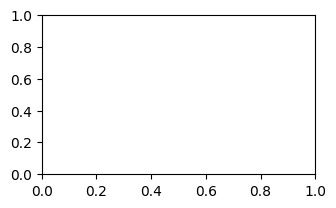

In [5]:
def dataset_train_processing():
    # Hardcode dataset path
    data_path =r'C:\SumMe\Frame\Bus in rock tunnel'
    augmented_data_path = r'C:\SumMe\Augmentation\AugBus\Aug'
    
    # Create the directory for augmented data if it doesn't exist
    if not os.path.exists(augmented_data_path):
        os.makedirs(augmented_data_path)
    
    # Process dataset
    file_names = os.listdir(data_path)
    
    # Set a datagenerator for augmentation
    train_datagen = ImageDataGenerator(rotation_range=15,
                                       shear_range=0.1,
                                       zoom_range=0.2,
                                       horizontal_flip=True,
                                       width_shift_range=0.1,
                                       height_shift_range=0.1)
    
    # Create batches of data for augmentation
    for file_name in file_names:
        image_path = os.path.join(data_path, file_name)
        img = plt.imread(image_path)
        img = img.reshape((1,) + img.shape)  # Reshape to add batch dimension
        
        # Flow the image through the generator and save augmented images
        i = 0
        for batch in train_datagen.flow(img, 
                                        batch_size=1,
                                        save_to_dir=augmented_data_path,
                                        save_prefix=f'aug_{os.path.splitext(file_name)[0]}',
                                        save_format='jpeg'):
            i += 1
            if i >= 1:  # Save 2 augmented versions of each image
                break
    
    # Sample visualization of augmented images (optional)
    example_gen = train_datagen.flow_from_directory(data_path,
                                                    target_size=(224, 224),
                                                    batch_size=1,
                                                    class_mode=None,
                                                    save_to_dir=augmented_data_path,
                                                    save_prefix='aug_example',
                                                    save_format='jpg')
    
    plt.figure(figsize=(12, 12))
    for i in range(0, 15):
        plt.subplot(5, 3, i + 1)
        for X in example_gen:
            image = X[0]
            plt.imshow(image)
            break
    plt.tight_layout()
    plt.show()

# Usage
dataset_train_processing()

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
import numpy as np
import os

# Load the InceptionV3 model
net = InceptionV3(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\AugBus'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in InceptionV3 (change as needed)
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'inceptionv3_features_train.npy'), features_train)

print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 149, 149, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 149, 149, 32  96         ['conv2d[0][0]']                 
 alization)                     )                                                      

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os


# Load the ResNet50 model
net = ResNet50(include_top=True, weights='imagenet')
net.summary()

# Load images from directory using ImageDataGenerator
image_directory = r'C:\SumMe\Augmentation\AugBus'
input_size = net.input_shape[1:3]  # Get the input size (height, width)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
# Create a data generator for the images
augimds = datagen.flow_from_directory(image_directory,
                                      target_size=input_size,
                                      batch_size=32,  # Adjust the batch size if needed
                                      class_mode=None,
                                      shuffle=False) 

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Create a model that outputs the activations from the specified layer
layer_name = 'predictions'  # Example layer name in ResNet50
intermediate_layer_model = tf.keras.Model(inputs=net.input,
                                          outputs=net.get_layer(layer_name).output)

# Generate activations
features_train = intermediate_layer_model.predict(augimds)
# Reshape the features to ensure they are in 'rows' format (2D)
features_train = features_train.reshape(features_train.shape[0], -1)
np.save(os.path.join(image_directory, 'resnet50_features_train.npy'), features_train)


print(f"Features shape: {features_train.shape}")

# Print some sample features
print("Sample features (first 5 rows):")
print(features_train[:5])

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           